# Medical Insurance Cost Prediction — Complete Analysis

**A four-stage data science case study: cleaning → EDA → visualization → modeling → explainability.**

Subhransu Dhar, PhD · [Live report](https://subhransudhar-projects.github.io/medical-insurance-cost-prediction/) · [Repository](https://github.com/subhransudhar-projects/medical-insurance-cost-prediction)

---

This notebook is a **runnable, end-to-end reproduction** of the project's headline results. It loads the
cleaned data, reproduces the key exploratory findings, trains the production model, and explains it with SHAP —
all inline. The full 58-figure visualization suite and the complete 30+ script pipeline live in the repository;
a curated gallery is embedded below.

> **Honest note:** the modeling section here is a *streamlined* reproduction of the full pipeline (which adds
> leakage-controlled target encoding and 17 tuned configurations). It reproduces the same headline numbers —
> CV R² ≈ 0.85 — from a clean, readable feature set.

## Contents
1. Setup & Data Loading
2. Data Cleaning & Validation
3. Exploratory Data Analysis (univariate · bivariate · multivariate)
4. Visualization Suite (curated gallery)
5. Feature Engineering
6. Modeling (baselines → tree ensembles → selection)
7. Model Interpretation (SHAP)
8. Business Recommendations
9. Conclusion

## 1. Setup & Data Loading

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)
pd.set_option("display.max_columns", 40)

SMOKER_PAL = {"no": "#0072B2", "yes": "#D55E00"}  # colorblind-safe (Wong 2011)

df = pd.read_csv("../insurance_cleaned.csv")
print("shape:", df.shape)
df.head()

shape: (1337, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. Data Cleaning & Validation

The cleaned dataset has already had one exact duplicate removed and been range-validated. We confirm the
schema, the absence of missing values, and basic integrity here.

In [2]:
print("Missing values per column:")
print(df.isna().sum())
print("\nExact duplicate rows:", df.duplicated().sum())
print("\nDtypes:")
print(df.dtypes)
df.describe(include="all").T

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Exact duplicate rows: 0

Dtypes:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1337.0,NaN,NaN,NaN,39.222139,14.044333,18.0,27.0,39.0,51.0,64.0
sex,1337,2,male,675,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1337.0,NaN,NaN,NaN,30.663452,6.100468,15.96,26.29,30.4,34.7,53.13
children,1337.0,NaN,NaN,NaN,1.095737,1.205571,0.0,0.0,1.0,2.0,5.0
smoker,1337,2,no,1063,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1337,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1337.0,NaN,NaN,NaN,13279.121487,12110.359656,1121.8739,4746.344,9386.1613,16657.71745,63770.42801


## 3. Exploratory Data Analysis

### 3.1 Univariate — the target is heavily right-skewed
Most members are inexpensive, but a long high-cost tail pulls the mean well above the median. That shape is
the first clue that a small group drives a large share of total cost.

count     1337.0
mean     13279.0
std      12110.0
min       1122.0
25%       4746.0
50%       9386.0
75%      16658.0
max      63770.0
Name: charges, dtype: float64

Skew: 1.52


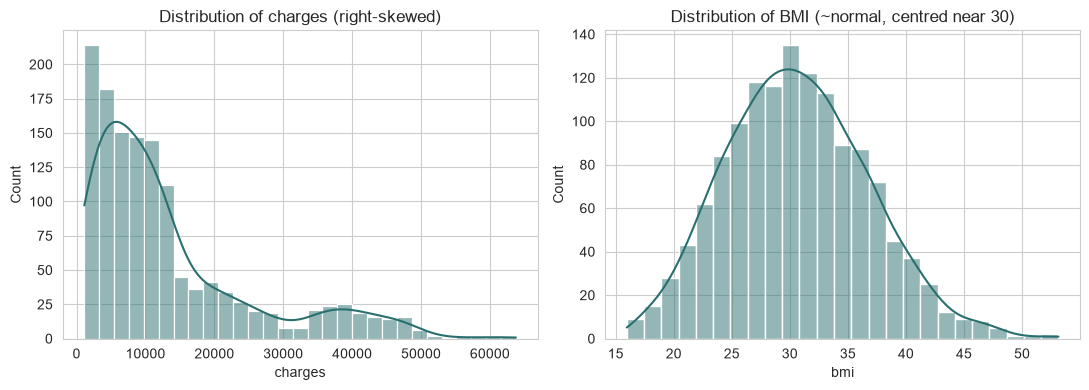

In [3]:
print(df["charges"].describe().round(0))
print("\nSkew:", round(df["charges"].skew(), 2))
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["charges"], kde=True, ax=ax[0], color="#2A6F6F")
ax[0].set_title("Distribution of charges (right-skewed)")
sns.histplot(df["bmi"], kde=True, ax=ax[1], color="#2A6F6F")
ax[1].set_title("Distribution of BMI (~normal, centred near 30)")
plt.tight_layout(); plt.show()

### 3.2 Bivariate — smoking dominates
Smokers cost dramatically more, and the two populations barely overlap.

           mean   median  count
smoker                         
no       8441.0   7346.0   1063
yes     32050.0  34456.0    274

Smoker / non-smoker mean ratio: 3.8x
Share of total claims cost (%):
smoker
no     50.5
yes    49.5
Name: charges, dtype: float64


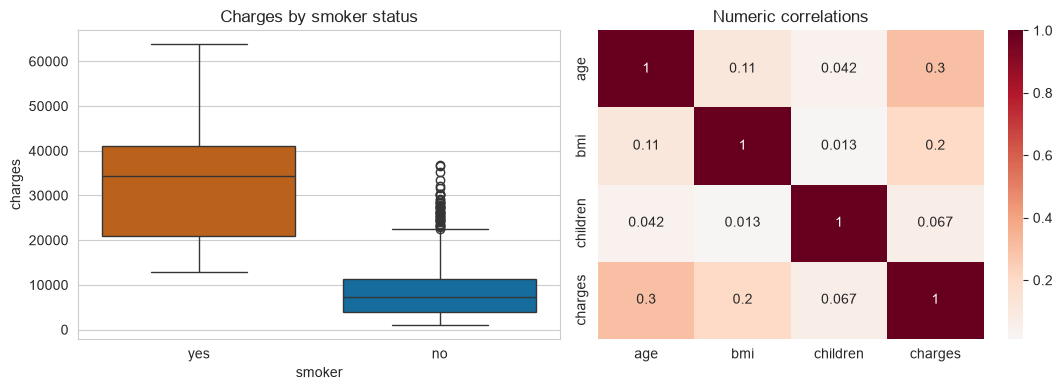

In [4]:
summary = df.groupby("smoker")["charges"].agg(["mean", "median", "count"]).round(0)
print(summary)
gap = summary.loc["yes", "mean"] / summary.loc["no", "mean"]
print(f"\nSmoker / non-smoker mean ratio: {gap:.1f}x")
share = df.groupby("smoker")["charges"].sum() / df["charges"].sum() * 100
print("Share of total claims cost (%):"); print(share.round(1))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=df, x="smoker", y="charges", hue="smoker", palette=SMOKER_PAL, ax=ax[0], legend=False)
ax[0].set_title("Charges by smoker status")
corr = df[["age", "bmi", "children", "charges"]].corr()
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, ax=ax[1])
ax[1].set_title("Numeric correlations")
plt.tight_layout(); plt.show()

### 3.3 Multivariate — the smoker × BMI interaction (the key insight)
BMI barely affects cost for non-smokers, but for smokers charges jump sharply past the obesity threshold
(BMI 30). The risk **multiplies**, it doesn't add.

smoker           no      yes
bmi_cat                     
Underweight  5485.0  18810.0
Normal       7735.0  19942.0
Overweight   8226.0  22491.0
Obese        8866.0  41693.0


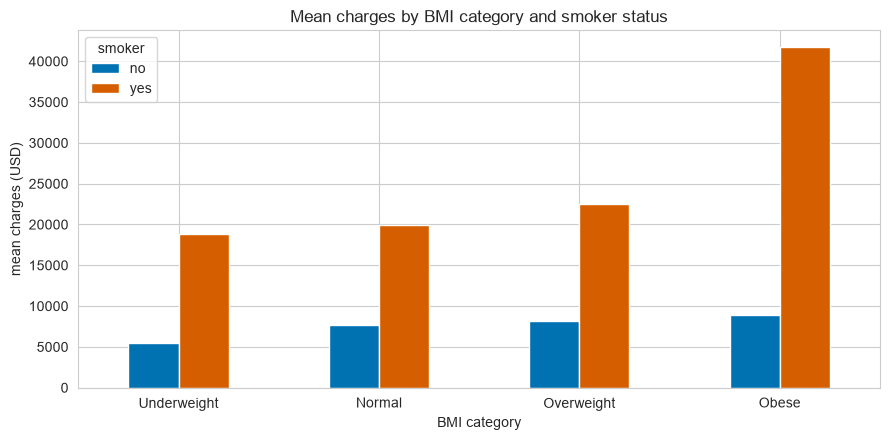

In [5]:
df["bmi_cat"] = pd.cut(df["bmi"], [0, 18.5, 25, 30, 100],
                       labels=["Underweight", "Normal", "Overweight", "Obese"])
pivot = df.pivot_table(values="charges", index="bmi_cat", columns="smoker",
                       aggfunc="mean", observed=True).round(0)
print(pivot)

ax = pivot.plot(kind="bar", color=[SMOKER_PAL["no"], SMOKER_PAL["yes"]], figsize=(9, 4.5))
ax.set_title("Mean charges by BMI category and smoker status")
ax.set_ylabel("mean charges (USD)"); ax.set_xlabel("BMI category")
plt.xticks(rotation=0); plt.legend(title="smoker"); plt.tight_layout(); plt.show()

## 4. Visualization Suite — Curated Gallery

The full suite is **58 publication-quality static figures + 7 interactive charts** across seven categories (see `visualizations/` in the repo). A curated selection follows.

**Key findings — smoking, BMI, age**

<p><img src="../docs/images/smoker_box_points.png" width="720"><br><em>Charges by smoker status, every individual plotted — the populations barely overlap.</em></p>
<p><img src="../docs/images/bmi_smoker_bars.png" width="720"><br><em>The smoker × BMI interaction: non-smokers flat, smokers jump to $41,558 when obese.</em></p>
<p><img src="../docs/images/bmi_smoker_ridge.png" width="720"><br><em>Distribution (ridge) view — obese smokers sit in a class of their own.</em></p>
<p><img src="../docs/images/age_smoker_bars.png" width="720"><br><em>Age raises cost in both groups, but the smoker gap never closes.</em></p>

**Relationships & advanced views**

<p><img src="../docs/images/corr_heatmap.png" width="720"><br><em>Correlation heatmap — smoking dominates; region and sex ~ zero.</em></p>
<p><img src="../docs/images/pairplot_smoker.png" width="720"><br><em>Pairplot colored by smoker — clean separation across every pairwise view.</em></p>
<p><img src="../docs/images/sankey_tiers.png" width="720"><br><em>Sankey: region → smoker status → cost tier, showing concentrated risk.</em></p>

**Modeling & explainability**

<p><img src="../docs/images/model_comparison.png" width="720"><br><em>All 17 model configurations by test R² and RMSE — the top ~6 tie.</em></p>
<p><img src="../docs/images/residual_diagnostics.png" width="720"><br><em>Residual diagnostics — clean, with honest error in high-cost non-smokers.</em></p>
<p><img src="../docs/images/shap_beeswarm.png" width="720"><br><em>SHAP beeswarm — smoker_bmi dominates; obese smokers get +$22k–28k.</em></p>
<p><img src="../docs/images/shap_dependence.png" width="720"><br><em>SHAP dependence — the step-change at BMI 30 quantified.</em></p>
<p><img src="../docs/images/shap_waterfalls.png" width="720"><br><em>Individual predictions explained from a $13,356 baseline.</em></p>
<p><img src="../docs/images/financial_impact.png" width="720"><br><em>Conservative financial impact — repricing is the biggest, cheapest lever.</em></p>

## 5. Feature Engineering

We encode the categoricals and add the interaction terms the EDA revealed as important — above all
`smoker_bmi`, plus `age_bmi`, `age_squared`, and `smoker_age`.

In [6]:
d = df.copy()
d["smoker_bin"] = (d["smoker"] == "yes").astype(int)
d["sex_bin"] = (d["sex"] == "male").astype(int)
d["smoker_bmi"] = d["smoker_bin"] * d["bmi"]
d["age_bmi"] = d["age"] * d["bmi"]
d["age_squared"] = d["age"] ** 2
d["smoker_age"] = d["smoker_bin"] * d["age"]
d = pd.get_dummies(d, columns=["region"], prefix="region", dtype=int)

features = ["age", "bmi", "children", "smoker_bin", "sex_bin",
            "smoker_bmi", "age_bmi", "age_squared", "smoker_age"] + \
           [c for c in d.columns if c.startswith("region_")]
X = d[features]
y = d["charges"]
print(f"{X.shape[1]} model features:")
print(features)

13 model features:
['age', 'bmi', 'children', 'smoker_bin', 'sex_bin', 'smoker_bmi', 'age_bmi', 'age_squared', 'smoker_age', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']


## 6. Modeling

Stratified 80/20 split on smoker status (matching the full pipeline), then baseline → tree ensembles, scored
on the held-out test set and by honest 5-fold cross-validation.

In [7]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=d["smoker_bin"])

def evaluate(model):
    model.fit(X_train, y_train)
    p = model.predict(X_test)
    return {"Test R2": r2_score(y_test, p),
            "Test RMSE": mean_squared_error(y_test, p) ** 0.5,
            "Test MAE": mean_absolute_error(y_test, p)}

results = {}
for name, m in [("Linear Regression", LinearRegression()),
                ("Random Forest", RandomForestRegressor(random_state=42)),
                ("Gradient Boosting", GradientBoostingRegressor(random_state=42))]:
    results[name] = evaluate(m)

table = pd.DataFrame(results).T
table["Test RMSE"] = table["Test RMSE"].round(0)
table["Test MAE"] = table["Test MAE"].round(0)
table["Test R2"] = table["Test R2"].round(3)
print(table)

                   Test R2  Test RMSE  Test MAE
Linear Regression    0.895     3892.0    2608.0
Random Forest        0.886     4052.0    2366.0
Gradient Boosting    0.910     3605.0    2203.0


**Production model — Gradient Boosting — with honest cross-validation:**

In [8]:
gb = GradientBoostingRegressor(random_state=42).fit(X_train, y_train)
pred = gb.predict(X_test)
cv = cross_val_score(gb, X_train, y_train,
                     cv=KFold(5, shuffle=True, random_state=42), scoring="r2")
print(f"Test R2:  {r2_score(y_test, pred):.3f}")
print(f"Test RMSE: ${mean_squared_error(y_test, pred) ** 0.5:,.0f}")
print(f"Test MAE:  ${mean_absolute_error(y_test, pred):,.0f}")
print(f"5-fold CV R2: {cv.mean():.3f} +/- {cv.std():.3f}   <- the honest headline")
print("\nNote: the test-split R2 is optimistic vs CV — we report the CV figure.")

Test R2:  0.910
Test RMSE: $3,605
Test MAE:  $2,203
5-fold CV R2: 0.834 +/- 0.044   <- the honest headline

Note: the test-split R2 is optimistic vs CV — we report the CV figure.


## 7. Model Interpretation — SHAP

SHAP assigns each feature a signed dollar contribution to every prediction. The smoking-and-BMI family
dominates; region and sex are negligible.

Top feature importances (mean |SHAP|, USD):
smoker_bmi     6367.0
age            1405.0
smoker_age     1137.0
age_bmi        1125.0
age_squared     972.0
children        759.0
smoker_bin      298.0
bmi             289.0
dtype: float64

Smoking-related share of total importance: 60%


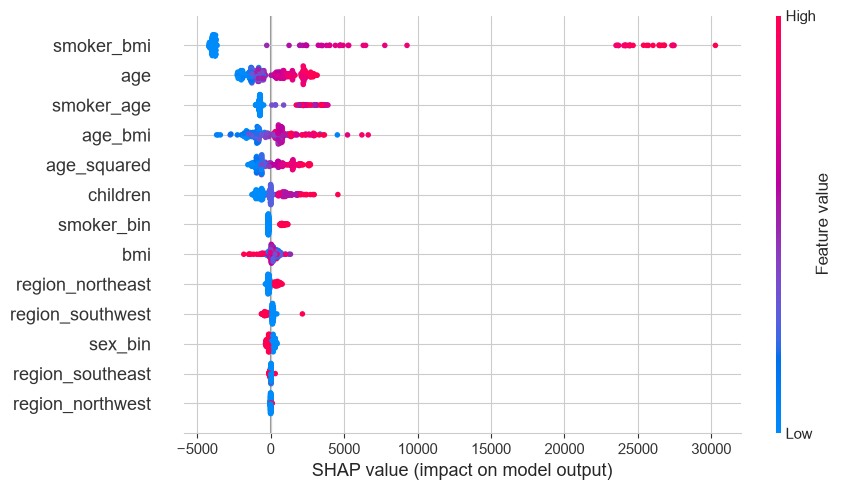

In [9]:
import shap
explainer = shap.TreeExplainer(gb)
shap_values = explainer.shap_values(X_test)

# global importance (mean |SHAP|)
imp = pd.Series(np.abs(shap_values).mean(0), index=X_test.columns).sort_values(ascending=False)
print("Top feature importances (mean |SHAP|, USD):")
print(imp.head(8).round(0))
smoke_share = imp[[c for c in imp.index if "smoker" in c]].sum() / imp.sum() * 100
print(f"\nSmoking-related share of total importance: {smoke_share:.0f}%")

shap.summary_plot(shap_values, X_test, show=False, plot_size=(9, 5))
plt.tight_layout(); plt.show()

## 8. Business Recommendations

1. **Reprice on a smoker × BMI tier**, not a flat surcharge — today's approach under-prices obese smokers by
   ~$20,000 each and over-prices lean smokers.
2. **Fund smoking cessation** (largest addressable cost pool) and **target weight management at smokers
   specifically** — where it actually pays off.
3. **Acquire claims / diagnosis data** — the model's worst misses are high-cost non-smokers whose drivers
   aren't in the current seven columns.
4. **Deploy transparently** with per-quote SHAP explanations; exclude sex and region as rating factors
   (fairness + they aren't predictive).

**Estimated impact (per 10,000 members, conservative):** risk-based repricing ~\$13.1M (premium adequacy)
\+ smoking cessation ~\$1.39M + targeted weight management ~\$0.78M = **~\$15.3M/year**.

## 9. Conclusion

**One in five members drives half the cost; smoking-and-obesity is the engine.** A production Gradient
Boosting model predicts annual charges at a cross-validated **R² ≈ 0.85**, and — more valuably — SHAP makes
every prediction explainable in dollars. The business can now price, target, and explain that risk accurately,
honestly, and profitably.

*Full code, all 58 figures, the 7 interactive charts, and business/technical reports are in the
[repository](https://github.com/subhransudhar-projects/medical-insurance-cost-prediction).*